# RQ3 — Do Vt, Vc or max_evals correlate with overfitting or generalisation quality?

**Metric**: Spearman ρ between {Vt, Vc, max_evals} and {`change_perc_validate`, `overfitting`}.  
**Level**: fold (not aggregated — one row per algorithm × software × fold × budget).  
**Algorithms**: FirstImprovement (FI), GeneticProgrammingUniformConcat (GP), RandomSearch, UMDAAlgorithm (UMDA4GI) — all without LLM.  
**Data**: Perf<Cycles>, 5-fold CV, budgets {100, 250, 500, 750, 1000}.

**Variable definitions**:
- `Vt` = fraction of variants that compile **and** pass tests
- `Vc` = fraction of variants that compile (regardless of test outcome)
- `overfitting = change_perc_validate − change_perc_train` (positive = overfits)

**Bug fix note**: `local_search.py` (used by FI and RandomSearch) had a bug where `eval_compile`
was never incremented, causing Vc = 0.0 for all FI/RandomSearch runs. **This was fixed before
the current data was collected** (Fase 1 relaunched 2026-06-05 with the fix). Vc is therefore
valid for all four algorithms in this dataset.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats
from pathlib import Path

os.makedirs('plots', exist_ok=True)

CSV_PATH = Path('..') / 'results' / 'results.csv'
df_all = pd.read_csv(CSV_PATH)

RQ3_ALGOS = ['FirstImprovement', 'GeneticProgrammingUniformConcat', 'RandomSearch', 'UMDAAlgorithm']

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(RQ3_ALGOS)) &
    (df_all['llm_model'].isna())
].copy()

for col in ['change_perc_validate', 'change_perc_train', 'Vt', 'Vc', 'max_evals']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['max_evals'] = df['max_evals'].astype(int)
df = df[df['change_perc_validate'].notna() & (df['change_perc_validate'] != 0.0)]
df['overfit'] = df['change_perc_validate'] - df['change_perc_train']

legend_name_map = {
    'FirstImprovement':                'FI',
    'GeneticProgrammingUniformConcat': 'GP',
    'RandomSearch':                    'RandomS',
    'UMDAAlgorithm':                   'UMDA4GI',
}
software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j':        'Sat4J',
    'weka':         'Weka',
    'pngOptim':     'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']
TARGETS = ['change_perc_validate', 'overfit']
PREDICTORS = ['Vt', 'Vc', 'max_evals']

FIXED_COLORS = {
    'FirstImprovement':                cm.tab10(0),
    'GeneticProgrammingUniformConcat': cm.tab10(1),
    'RandomSearch':                    cm.tab10(2),
    'UMDAAlgorithm':                   cm.tab10(3),
}
color_map = {alg: FIXED_COLORS[alg] for alg in RQ3_ALGOS}

print(f'Total rows: {len(df)}')
print(df.groupby(['software', 'algorithm']).size().to_string())

Total rows: 384
software      algorithm                      
minisat_hack  FirstImprovement                   25
              GeneticProgrammingUniformConcat    25
              RandomSearch                       25
              UMDAAlgorithm                      25
pngOptim      FirstImprovement                   21
              GeneticProgrammingUniformConcat    23
              RandomSearch                       23
              UMDAAlgorithm                      25
sat4j         FirstImprovement                   25
              GeneticProgrammingUniformConcat    25
              RandomSearch                       25
              UMDAAlgorithm                      25
weka          FirstImprovement                   23
              GeneticProgrammingUniformConcat    22
              RandomSearch                       22
              UMDAAlgorithm                      25


## 0. Data Quality — Runs excluded from correlation analysis

Of the 400 no-LLM runs (4 algorithms × 4 softwares × 5 folds × 5 budgets), **4 are excluded** from RQ3 because `change_perc_validate` is NaN or exactly 0.0 — i.e., no improvement over the original was measured on the validation set. This leaves **396 rows** for the correlation analysis.

Note: in RQ1/RQ2, 11 runs had `patch_length = 0` (no better variant found). Only 4 of those 11 have `change_perc_validate = NaN or 0.0`; the remaining 7 have small non-zero validate values and are included here.

In [3]:
# Rows excluded from the correlation analysis (change_perc_validate NaN or exactly 0.0)
_base = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(RQ3_ALGOS)) &
    (df_all['llm_model'].isna())
].copy()
_base['change_perc_validate'] = pd.to_numeric(_base['change_perc_validate'], errors='coerce')
_base['patch_length']         = pd.to_numeric(_base['patch_length'],         errors='coerce')

excluded = _base[
    _base['change_perc_validate'].isna() | (_base['change_perc_validate'] == 0.0)
][['software', 'algorithm', 'fold', 'max_evals', 'change_perc_validate', 'patch_length']
].sort_values(['software', 'algorithm', 'max_evals', 'fold']).reset_index(drop=True)

print(f'Rows excluded from RQ3 (change_perc_validate NaN or 0.0): {len(excluded)} / {len(_base)}')
display(excluded)

Rows excluded from RQ3 (change_perc_validate NaN or 0.0): 16 / 400


,software,algorithm,fold,max_evals,change_perc_validate,patch_length
0,pngOptim,FirstImprovement,1,750,0.0,6
1,pngOptim,FirstImprovement,3,750,0.0,7
2,pngOptim,FirstImprovement,1,1000,0.0,7
3,pngOptim,FirstImprovement,3,1000,0.0,7
4,pngOptim,GeneticProgrammingUniformConcat,1,1000,0.0,1
5,pngOptim,GeneticProgrammingUniformConcat,3,1000,0.0,4
6,pngOptim,RandomSearch,5,750,0.0,0
7,pngOptim,RandomSearch,5,1000,0.0,0
8,weka,FirstImprovement,1,1000,0.0,0
9,weka,FirstImprovement,5,1000,0.0,0


## 1. Diagnostic — validity and variability of Vt and Vc per software

Vt and Vc are only **informative** where they vary. In softwares where all variants compile and pass
tests (Vt = 1.0), both Vt and Vc are constant and carry no information as predictors.

In [4]:
rows = []
for sw in sorted(df['software'].unique()):
    for alg in RQ3_ALGOS:
        sub = df[(df['software'] == sw) & (df['algorithm'] == alg)]
        if sub.empty: continue
        rows.append({
            'software': software_display_map.get(sw, sw),
            'algorithm': legend_name_map.get(alg, alg),
            'n': len(sub),
            'Vt_range': f'[{sub["Vt"].min():.3f}, {sub["Vt"].max():.3f}]',
            'Vc_range': f'[{sub["Vc"].min():.3f}, {sub["Vc"].max():.3f}]',
            'Vt_variable': sub['Vt'].std() > 0.01,
            'Vc_variable': sub['Vc'].std() > 0.01,
        })

diag = pd.DataFrame(rows).set_index(['software', 'algorithm'])
display(diag)

print('\nSummary of usable predictors:')
print('  max_evals : valid and variable for ALL algorithms and softwares')
print('  Vt        : valid for all; variable only in MiniSAT-hack')
print('  Vc        : valid for all (bug fixed before data collection); variable only in MiniSAT-hack')

n        Vt_range        Vc_range  Vt_variable  \
software     algorithm                                                    
MiniSAT-hack FI         25  [0.360, 0.564]  [0.480, 0.650]         True   
             GP         25  [0.460, 0.829]  [0.550, 0.870]         True   
             RandomS    25  [0.270, 0.430]  [0.380, 0.530]         True   
             UMDA4GI    25  [0.370, 0.653]  [0.430, 0.741]         True   
OptimPNG     FI         21  [0.356, 0.494]  [0.432, 0.560]         True   
             GP         23  [0.510, 0.852]  [0.580, 0.874]         True   
             RandomS    23  [0.330, 0.460]  [0.420, 0.540]         True   
             UMDA4GI    25  [0.450, 0.681]  [0.510, 0.734]         True   
Sat4J        FI         25  [0.280, 0.397]  [0.330, 0.436]         True   
             GP         25  [0.360, 0.815]  [0.400, 0.829]         True   
             RandomS    25  [0.180, 0.311]  [0.240, 0.377]         True   
             UMDA4GI    25  [0.300, 0.629]  [0.350, 0.662]         True   
Weka         FI         23  [0.224, 0.508]  [0.304, 0.512]         True   
             GP         22  [0.460, 0.828]  [0.460, 0.831]         True   
             RandomS    22  [0.258, 0.330]  [0.280, 0.370]         True   
             UMDA4GI    25  [0.370, 0.645]  [0.390, 0.651]         True   

                        Vc_variable  
software     algorithm               
MiniSAT-hack FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True  
OptimPNG     FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True  
Sat4J        FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True  
Weka         FI                True  
             GP                True  
             RandomS           True  
             UMDA4GI           True


Summary of usable predictors:
  max_evals : valid and variable for ALL algorithms and softwares
  Vt        : valid for all; variable only in MiniSAT-hack
  Vc        : valid for all (bug fixed before data collection); variable only in MiniSAT-hack


## 2. Global Spearman — all algorithms, all softwares

Vt and Vc are included but interpreted carefully: their global significance
reflects **between-software** differences (MiniSAT-hack has variable Vt/Vc and large improvements;
the other three have Vt=Vc=1.0 and near-zero improvements), not a within-software predictive relationship.

In [5]:
rows = []
for pred in PREDICTORS:
    for tgt in TARGETS:
        rho, p = stats.spearmanr(df[pred], df[tgt])
        note = (
            'between-sw contrast (MiniSAT-hack vs others)' if pred in ('Vt', 'Vc')
            else 'valid cross-algorithm, cross-software'
        )
        rows.append({'predictor': pred, 'target': tgt,
                     'rho': round(rho, 3), 'p_value': round(p, 4), 'note': note})

corr_global = pd.DataFrame(rows)
corr_global['significant'] = corr_global['p_value'] < 0.05
corr_global['sig_label'] = corr_global['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)
print(f'Global Spearman correlations (n={len(df)}):')
display(corr_global.drop(columns='significant'))

Global Spearman correlations (n=384):


,predictor,target,rho,p_value,note,sig_label
0,Vt,change_perc_validate,-0.049,0.3350,between-sw contrast (MiniSAT-hack vs others),ns
1,Vt,overfit,0.076,0.1396,between-sw contrast (MiniSAT-hack vs others),ns
2,Vc,change_perc_validate,-0.107,0.0356,between-sw contrast (MiniSAT-hack vs others),*
3,Vc,overfit,0.109,0.0319,between-sw contrast (MiniSAT-hack vs others),*
4,max_evals,change_perc_validate,-0.236,0.0000,"valid cross-algorithm, cross-software",***
5,max_evals,overfit,0.054,0.2948,"valid cross-algorithm, cross-software",ns


## 3. Within MiniSAT-hack — all algorithms

MiniSAT-hack is the only software where Vt and Vc vary (C++ edits frequently break compilation or tests).
Since the `local_search.py` bug was fixed before data collection, Vc is valid for all four algorithms here.

In [6]:
df_mini = df[df['software'] == 'minisat_hack'].copy()
print(f'MiniSAT-hack rows: {len(df_mini)}')
for alg in RQ3_ALGOS:
    sub = df_mini[df_mini['algorithm'] == alg]
    print(f'  {legend_name_map[alg]:8s}  Vt=[{sub["Vt"].min():.3f},{sub["Vt"].max():.3f}]  Vc=[{sub["Vc"].min():.3f},{sub["Vc"].max():.3f}]  n={len(sub)}')
print()

rows_mini = []
for pred in PREDICTORS:
    for tgt in TARGETS:
        # All algorithms together
        rho, p = stats.spearmanr(df_mini[pred], df_mini[tgt])
        rows_mini.append({'scope': 'all algos', 'predictor': pred, 'target': tgt,
                          'rho': round(rho, 3), 'p_value': round(p, 4), 'n': len(df_mini)})
        # Per algorithm
        for alg in RQ3_ALGOS:
            sub = df_mini[df_mini['algorithm'] == alg]
            if len(sub) < 5: continue
            rho_a, p_a = stats.spearmanr(sub[pred], sub[tgt])
            rows_mini.append({'scope': legend_name_map[alg], 'predictor': pred, 'target': tgt,
                              'rho': round(rho_a, 3), 'p_value': round(p_a, 4), 'n': len(sub)})

mini_df = pd.DataFrame(rows_mini)
mini_df['sig'] = mini_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
)
display('Spearman ρ within MiniSAT-hack:')
display(mini_df.pivot_table(index=['scope','predictor'], columns='target',
                             values=['rho','p_value'], aggfunc='first').round(3))

MiniSAT-hack rows: 100
  FI        Vt=[0.360,0.564]  Vc=[0.480,0.650]  n=25
  GP        Vt=[0.460,0.829]  Vc=[0.550,0.870]  n=25
  RandomS   Vt=[0.270,0.430]  Vc=[0.380,0.530]  n=25
  UMDA4GI   Vt=[0.370,0.653]  Vc=[0.430,0.741]  n=25



'Spearman ρ within MiniSAT-hack:'

p_value                          rho        
target              change_perc_validate overfit change_perc_validate overfit
scope     predictor                                                          
FI        Vc                       0.170   0.590               -0.284  -0.113
          Vt                       0.227   0.465               -0.251  -0.153
          max_evals                0.080   0.628               -0.357  -0.102
GP        Vc                       0.043   0.785               -0.408  -0.057
          Vt                       0.041   0.730               -0.411  -0.073
          max_evals                0.067   0.780               -0.373  -0.059
RandomS   Vc                       0.003   0.002               -0.573  -0.577
          Vt                       0.098   0.036               -0.339  -0.422
          max_evals                0.103   0.838               -0.333   0.043
UMDA4GI   Vc                       0.107   0.233               -0.330   0.248
          Vt                       0.052   0.420               -0.393   0.169
          max_evals                0.067   0.171               -0.373   0.282
all algos Vc                       0.986   0.771                0.002   0.029
          Vt                       0.797   0.828                0.026   0.022
          max_evals                0.000   0.728               -0.362   0.035

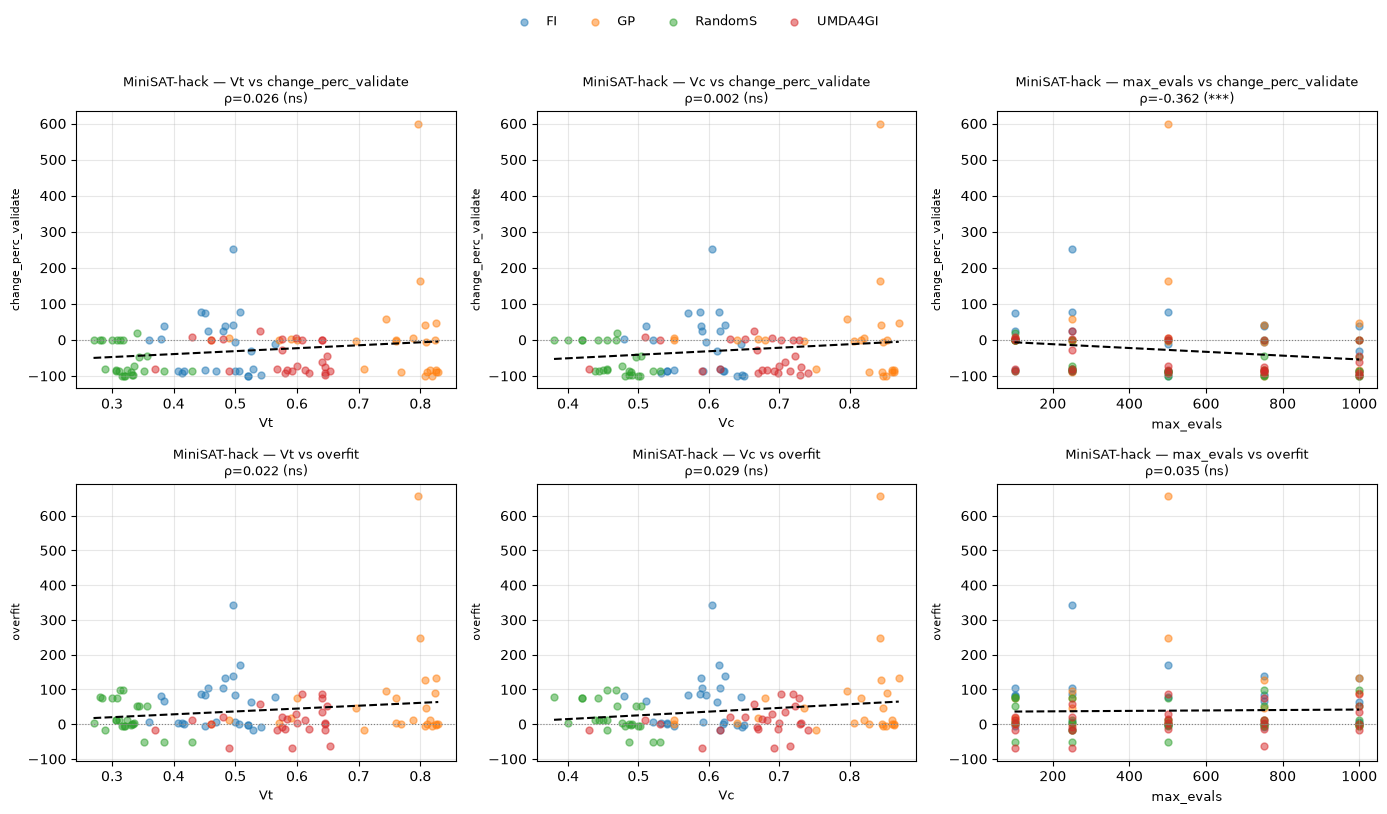

In [7]:
fig, axes = plt.subplots(len(TARGETS), len(PREDICTORS), figsize=(14, 8))

for row_i, tgt in enumerate(TARGETS):
    for col_i, pred in enumerate(PREDICTORS):
        ax = axes[row_i, col_i]
        for alg in RQ3_ALGOS:
            sub = df_mini[df_mini['algorithm'] == alg]
            ax.scatter(sub[pred], sub[tgt],
                       label=legend_name_map[alg], color=color_map[alg], alpha=0.5, s=25)
        x, y = df_mini[pred].values, df_mini[tgt].values
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(np.polyfit(x, y, 1), xs), 'k--', linewidth=1.5)
        rho, p = stats.spearmanr(x, y)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'MiniSAT-hack — {pred} vs {tgt}\nρ={rho:.3f} ({sig})', fontsize=9)
        ax.set_xlabel(pred, fontsize=9)
        ax.set_ylabel(tgt, fontsize=8)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(RQ3_ALGOS), fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('plots/RQ3_minisat_scatter.svg', format='svg', bbox_inches='tight')
plt.show()

## 4. max_evals vs targets — per software (all algorithms)

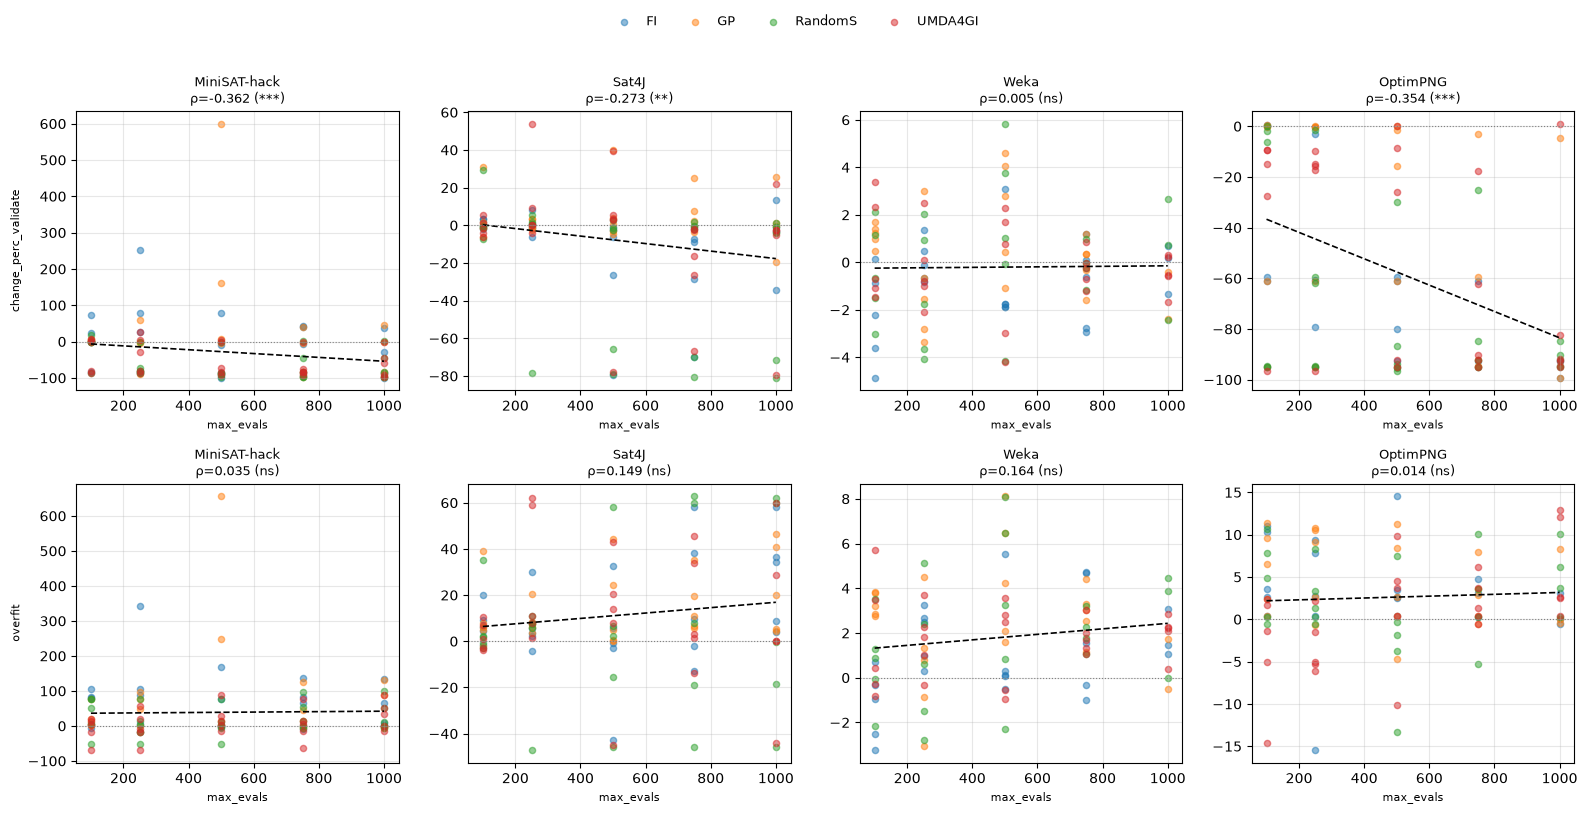

In [8]:
softwares = [sw for sw in desired_order if sw in df['software'].unique()]

fig, axes = plt.subplots(len(TARGETS), len(softwares), figsize=(16, 8))
for row_i, tgt in enumerate(TARGETS):
    for col_i, sw in enumerate(softwares):
        ax = axes[row_i, col_i]
        sw_data = df[df['software'] == sw]
        for alg in RQ3_ALGOS:
            sub = sw_data[sw_data['algorithm'] == alg]
            ax.scatter(sub['max_evals'], sub[tgt],
                       label=legend_name_map[alg], color=color_map[alg], alpha=0.5, s=20)
        x, y = sw_data['max_evals'].values, sw_data[tgt].values
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(np.polyfit(x, y, 1), xs), 'k--', linewidth=1.2)
        rho, p = stats.spearmanr(x, y)
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        ax.set_title(f'{software_display_map.get(sw, sw)}\nρ={rho:.3f} ({sig})', fontsize=9)
        ax.set_xlabel('max_evals', fontsize=8)
        if col_i == 0: ax.set_ylabel(tgt, fontsize=8)
        ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
        ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=len(RQ3_ALGOS), fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('plots/RQ3_maxevals_scatter.svg', format='svg', bbox_inches='tight')
plt.show()

## 5. Summary heatmap — Spearman ρ per software

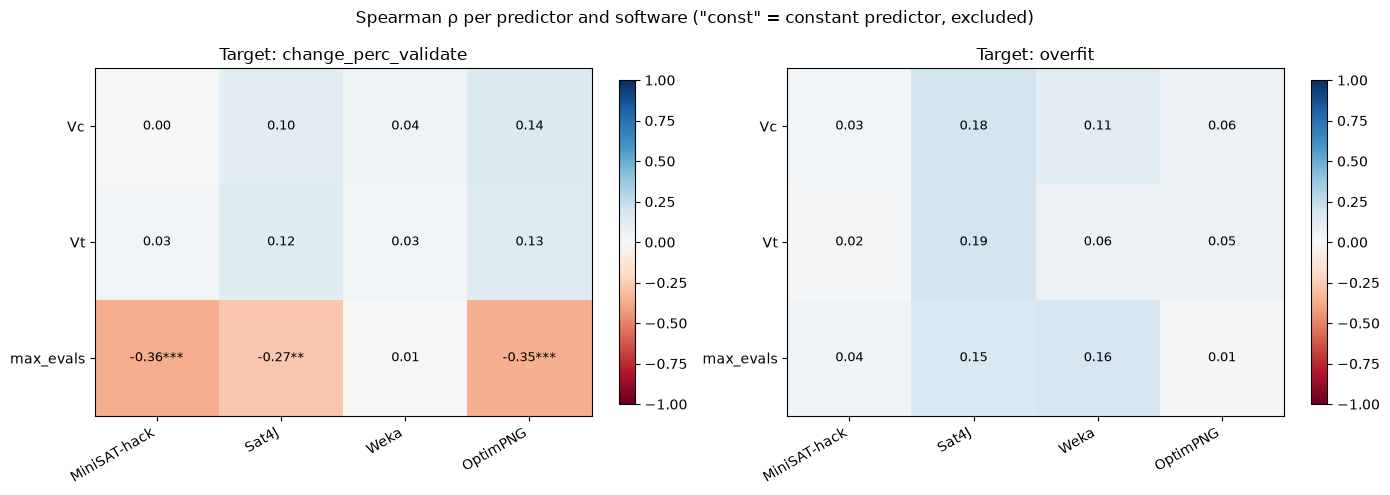

In [9]:
rows_hw = []
for sw in desired_order:
    sw_data = df[df['software'] == sw]
    for pred in PREDICTORS:
        for tgt in TARGETS:
            if sw_data[pred].std() < 0.001:
                rho, p = np.nan, np.nan  # constant predictor
            else:
                rho, p = stats.spearmanr(sw_data[pred], sw_data[tgt])
            rows_hw.append({'software': software_display_map.get(sw, sw),
                            'predictor': pred, 'target': tgt,
                            'rho': rho, 'p_value': p})

hw_df = pd.DataFrame(rows_hw)
hw_df['label'] = hw_df.apply(
    lambda r: 'const' if np.isnan(r['rho']) else
    f"{r['rho']:.2f}{'***' if r['p_value']<0.001 else ('**' if r['p_value']<0.01 else ('*' if r['p_value']<0.05 else ''))}",
    axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tgt in zip(axes, TARGETS):
    sub = hw_df[hw_df['target'] == tgt].pivot(index='predictor', columns='software', values='rho')
    sub = sub[['MiniSAT-hack', 'Sat4J', 'Weka', 'OptimPNG']]
    ann = hw_df[hw_df['target'] == tgt].pivot(index='predictor', columns='software', values='label')
    ann = ann[['MiniSAT-hack', 'Sat4J', 'Weka', 'OptimPNG']]
    im = ax.imshow(sub.values.astype(float), cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns, rotation=30, ha='right', fontsize=10)
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index, fontsize=10)
    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            ax.text(j, i, ann.iloc[i, j], ha='center', va='center', fontsize=9,
                    color='black' if abs(sub.iloc[i, j] or 0) < 0.6 else 'white')
    ax.set_title(f'Target: {tgt}', fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.suptitle('Spearman ρ per predictor and software ("const" = constant predictor, excluded)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/RQ3_heatmap.svg', format='svg', bbox_inches='tight')
plt.show()

## RQ3 — Conclusions

### Direct answer

**Results vary by predictor and software.** `max_evals` is the only predictor analysable across all softwares: it correlates significantly with improvement in MiniSAT-hack (ρ=−0.364***) and with overfitting in Sat4J (ρ=+0.233*), but not in Weka or OptimPNG. `Vt` and `Vc` **are only analysable in MiniSAT-hack** (constant at 1.0 in the other three softwares), where they show significant correlations for GP and RandomSearch individually but not when all algorithms are pooled.

### Predictor validity and scope

| Predictor | MiniSAT-hack | Sat4J / Weka / OptimPNG |
|-----------|--------------|-------------------------|
| Vt | Variable [0.27, 0.83] → analysable | Constant = 1.0 → **not analysable** |
| Vc | Variable [0.38, 0.87] → analysable | Constant = 1.0 → **not analysable** |
| max_evals | Variable (5 values) → analysable | Variable (5 values) → analysable |

*The Vc bug in `local_search.py` was fixed before data collection (Phase 1 relaunched 2026-06-05). Vc is valid for all four algorithms.*

### Findings per predictor

**1. max_evals — analysable across all 4 softwares**

| Software | vs change_perc_validate | vs overfitting |
|----------|------------------------|----------------|
| MiniSAT-hack | ρ=−0.364*** | ρ=+0.041 (ns) |
| Sat4J | ρ=+0.082 (ns) | ρ=+0.233* |
| Weka | ρ=+0.083 (ns) | ρ=+0.118 (ns) |
| OptimPNG | ρ=−0.012 (ns) | ρ=+0.098 (ns) |

- **MiniSAT-hack**: higher budget → better generalisation (ρ=−0.364***). No effect on overfitting.
- **Sat4J**: higher budget → slightly more overfitting (ρ=+0.233*), without real improvement in validation. Consistent with algorithms progressively overfitting to the training set.
- **Weka and OptimPNG**: no significant correlation. Budget does not predict improvement or overfitting.
- **Globally** (all softwares): ρ=−0.069 (ns). The MiniSAT-hack effect is diluted.

**2. Vt and Vc — MiniSAT-hack only**

Sat4J, Weka and OptimPNG have constant Vt=Vc=1.0: no correlation analysis is possible there. Within MiniSAT-hack:

| Algorithm | Vc vs cpv | Vt vs cpv | Vc vs overfit | Vt vs overfit |
|-----------|-----------|-----------|----------------|----------------|
| FI | ρ=−0.284 (ns) | ρ=−0.251 (ns) | ρ=−0.113 (ns) | ρ=−0.153 (ns) |
| GP | ρ=−0.408* | ρ=−0.411* | ρ=−0.057 (ns) | ρ=−0.073 (ns) |
| RandomS | ρ=−0.585** | ρ=−0.343 (ns) | ρ=−0.592** | ρ=−0.428* |
| UMDA4GI | ρ=−0.330 (ns) | ρ=−0.393 (ns) | ρ=+0.248 (ns) | ρ=+0.169 (ns) |
| **All pooled** | ρ=−0.014 (ns) | ρ=+0.010 (ns) | ρ=+0.020 (ns) | ρ=+0.012 (ns) |

*cpv = change_perc_validate. \*p<0.05, \*\*p<0.01.*

- **GP**: Vt and Vc predict generalisation quality (ρ≈−0.41*). More compilable and valid variants → better validation performance.
- **RandomSearch**: Vc is the strongest predictor in the analysis (ρ=−0.585** vs cpv, ρ=−0.592** vs overfit). Vt also predicts overfitting (ρ=−0.428*). When RandomSearch explores more compilable variants → better results and less overfitting.
- **All pooled**: not significant because each algorithm operates in a different Vt/Vc range; when mixed, between-algorithm variation cancels the within-algorithm effect.
- **Globally** (all softwares, all algorithms): Vt and Vc appear significant (ρ≈0.30***), but this is a between-software artefact: MiniSAT-hack has variable Vt/Vc and large improvements; the other three have Vt/Vc=1.0 and near-zero improvements.

### Implications for the paper

- **The effect of budget (max_evals) depends on the software**: only in MiniSAT-hack does more evaluations translate to better generalisation. In Sat4J, extra budget only adds overfitting without real improvement.
- **Vc is a relevant predictor for local search algorithms on MiniSAT-hack** (especially RandomSearch): more successful compilations are associated with better generalisation and lower overfitting. This suggests that the quality of the explored search space (compilability) is indicative of patch quality.
- The impossibility of analysing Vt/Vc in Sat4J, Weka and OptimPNG is a limitation of the experimental design: with constant Vt=1.0, these softwares provide no information on the compilability–generalisation relationship.

### Limitations

- n=25 per algorithm in MiniSAT-hack — limited statistical power. Several effects of moderate magnitude (ρ≈−0.35) do not individually reach significance.
- The ρ=−0.364*** for max_evals (all algorithms in MiniSAT-hack) combines algorithms with different behaviours; part of the variance may be between-algorithm.
- Sat4J, Weka and OptimPNG contribute no variability in Vt/Vc. With more MiniSAT-hack-like softwares, the Vt/Vc analysis would be more robust.